Transfer learning
- is a technique where a model trained on one large dataset/task is reused as the starting point for a different but related task.

Flow

Large Dataset → Pre-trained Model → Reuse Learned Features → Fine-tune on New Dataset → New Model

Example with CNN:
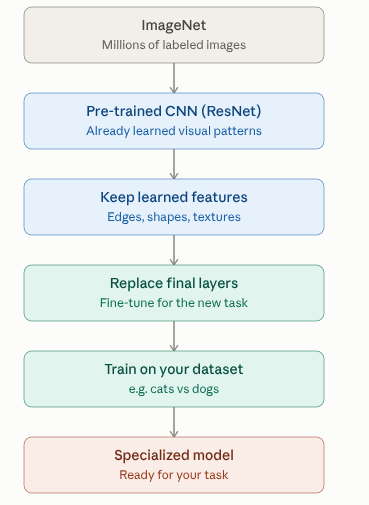

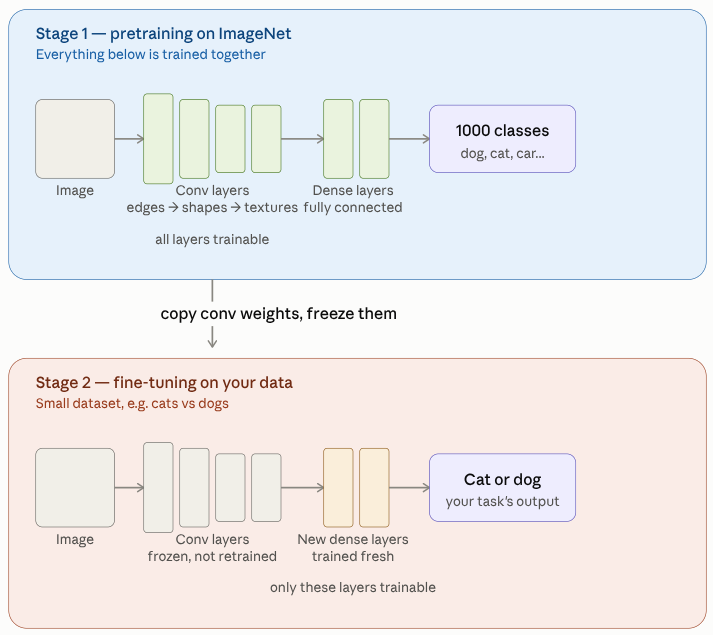

Stage 1 — Pretraining (large dataset)
The full CNN — conv layers and dense layers (fully connected layers) — trains end-to-end on a huge dataset like ImageNet. Early conv layers learn generic patterns (edges, textures, shapes), later ones learn more complex combinations, and the dense layers learn to classify into ImageNet's ~1000 classes. This takes a lot of data and compute, which is why we don't repeat it ourselves.

Stage 2 — Fine-tuning (your small dataset)
You keep the pretrained conv layers as-is (frozen) since edges and textures are useful for almost any image task. You throw away the old dense layers (they were built for ImageNet's classes) and attach new dense layers suited to your problem — e.g. 2 outputs for cats vs dogs. Only these new layers get trained, using your small dataset. Since the conv layers already know how to "see," a small dataset is enough to teach the new layers what to do with that vision.

Note: Dense layers = fully connected layers — every neuron connects to every neuron in the previous layer. They sit at the end of the CNN and act as the classifier, turning the features extracted by the conv layers into a final prediction.

Why it works: low-level visual features (edges, corners, colors) are universal — a cat detector and an X-ray detector both need them. Transfer learning reuses that expensive, general knowledge and only spends new training effort on the task-specific decision layer.

In [1]:
# Problem Statement
# Model : VGG-16  [CNN Based][Trained on Imagenet][Trained on 1.4 Million dataset]
# -> we will utilize the feature extraction part
# -> will detatch the classifier and
# -> will attach our's classifier [10 classes]
# -> and freeze the weights of the feature extraction layer
# -> Train model on our dataset

# Imagenet -> Based on the color dataset
# In our case -> grey scale dataset
# 1. DATA PREPARATION :
#           : [Need some data prep from our end, in order to get the correct image format to use VVG-16]
#           : our image is in tabular format (1,784)
#           : Reshape -> (1, 28, 28) : 2d matrix
#           : Change datatype of items of matrix -> (np.uint8)
#           : Change in 3d : (1, 28, 28) -> (3, 28, 28) : a tensor
#           : Tensor -> PIL Image

# 2. RESIZE :    (3, 28, 28) -> (3, 256, 256)
# 3. CENTER CROP
#           : (3, 256, 256) -> (3, 224, 224)
# 4. CONVERT TO PYTORCH TENSOR AND SCALE
#           : scale ->(0, 1)
# 5. NORMALIZE USING MEAN AND STD DEVIATION VALUES
#           : currently we have (3, 224, 224) image have 3 channels
#           : normalize each channel separately
#           : ex: pick each pixel of each channel like i picked p1 of channel 1
#           : p1 = (p1 - u)d
#           : where p1 is pixel, u is mean of that channel and d is stdd of that channel

#           : IN IMAGENET
#           : [0.485, 0.456, 0.406] (Mean of RED Channel, GREEN Channel AND GREEN Channel )
#           : [0.229, 0.224, 0.225] (STDD of RED Channel, GREEN Channel AND GREEN Channel )

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [4]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape

(60000, 785)

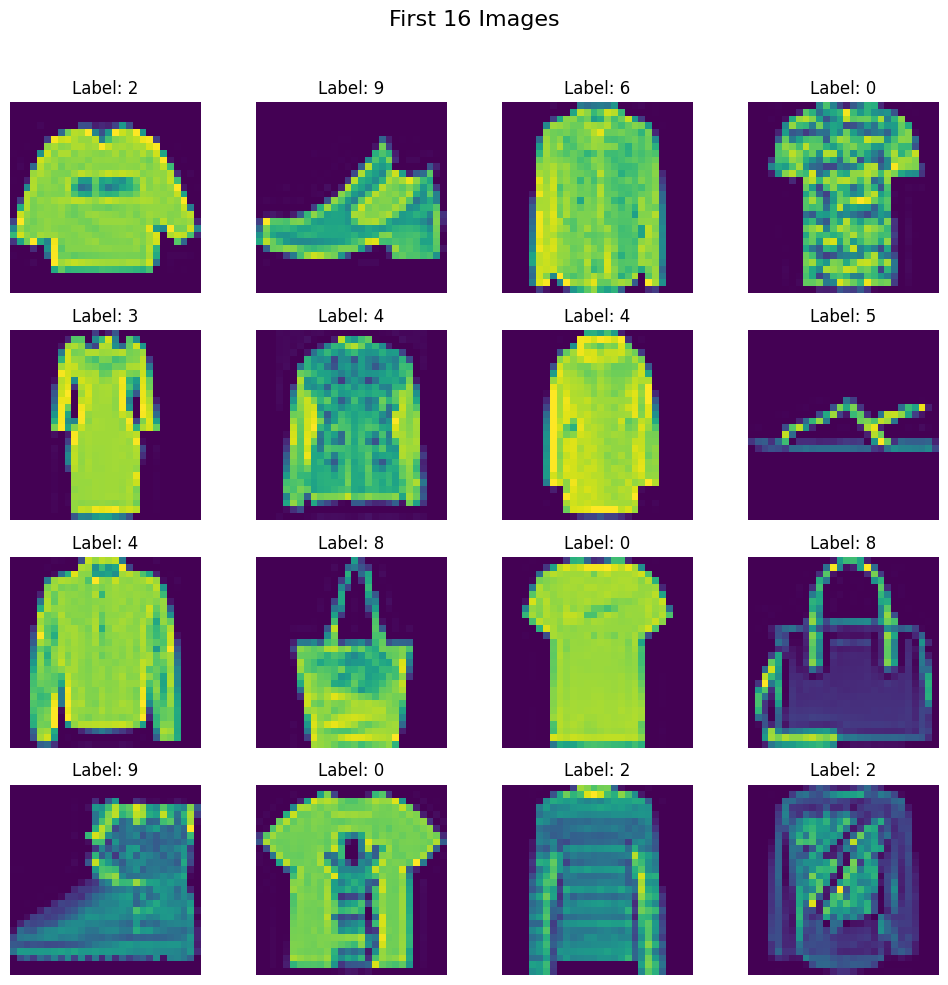

In [7]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [8]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# TRANSFORMATIONS [RESIZE, CENTER CROP, TENSOR CONVERSION AND NORMALIZE]
# INTERNPOLATION TECHNIQUE WITH RESIZE : BILINEAR : we get default at Resize(256)
# ToTensor performs two tasks [convert into tensors and convert/scale pixel into 0 and 1]
from torchvision.transforms import transforms

# DEFINE
custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [11]:
from PIL import Image
import numpy as np

class CustomDataset(Dataset):
  def __init__(self, features, labels, transform):
    self.features = features
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    # resize image here -> (28,28) and
    image = self.features[index].reshape(28, 28)

    # convert dtype to np.uint8
    image = image.astype(np.uint8)

    # change grey[black and white] -> colored [1->3]channel[1d->3d]
    # axis=-1 : because PIL need (H, W, C) but we have (C, H, W)
    image = np.stack([image]*3, axis=-1)

    # convert array to PIL image
    image = Image.fromarray(image)

    # apply transforms [now we can apply the transformations as we have PIL now]
    # all transformations will get apply at once
    image = self.transform(image)

    # return [image is already in tensor]
    return image, torch.tensor(self.labels[index], dtype=torch.long)


In [12]:
# DATASET
train_dataset = CustomDataset(X_train, y_train, transform=custom_transform)
test_dataset = CustomDataset(X_test, y_test, transform=custom_transform)

In [13]:
# DATALOADER
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [14]:
# MODEL TRAINING
# FETCH PRE-TRAINED MODEL
# import torchvision.models as models

# vgg16 = models.vgg16(pretrained=True)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 167MB/s]


In [15]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [16]:
vgg16.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [17]:
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [18]:
# MODEL
# FETCH PRE-TRAINED MODEL
import torchvision.models as models
vgg16 = models.vgg16(pretrained=True)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [19]:
# FREEZING WEIGHTS OF FEATURES
for param in vgg16.features.parameters():
  param.requires_grad=False

In [20]:
# REPLACING THE DEFAULT CLASSIFIER WITH OURS [ARCH.]
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 10)
)

In [21]:
# FROZEN
vgg16.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [22]:
# NOW OUR CLASSIFIER :
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=1024, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=1024, out_features=512, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=512, out_features=10, bias=True)
)

In [23]:
# MOVE OUR MODEL TO GPU
vgg16 = vgg16.to(device)

In [24]:
learning_rate = 0.0001
epochs = 10  #just for testing as it will take a lot of time

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=learning_rate)
# now it will udpate over only classifier params

In [26]:
# TRAINING LOOP
# ONLY CHANGE : model->vgg16

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = vgg16(batch_features)

    print(outputs.shape)
    print(batch_labels.shape)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

    break

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


torch.Size([32, 10])
torch.Size([32])
Epoch: 1 , Loss: 0.0015502527554829915
torch.Size([32, 10])
torch.Size([32])
Epoch: 2 , Loss: 0.0015172942479451496
torch.Size([32, 10])
torch.Size([32])
Epoch: 3 , Loss: 0.0014888671239217121
torch.Size([32, 10])
torch.Size([32])
Epoch: 4 , Loss: 0.001426385243733724
torch.Size([32, 10])
torch.Size([32])
Epoch: 5 , Loss: 0.0013849887847900391
torch.Size([32, 10])
torch.Size([32])
Epoch: 6 , Loss: 0.0014089455604553223
torch.Size([32, 10])
torch.Size([32])
Epoch: 7 , Loss: 0.0013028478622436523
torch.Size([32, 10])
torch.Size([32])
Epoch: 8 , Loss: 0.001295942783355713
torch.Size([32, 10])
torch.Size([32])
Epoch: 9 , Loss: 0.001196231206258138
torch.Size([32, 10])
torch.Size([32])
Epoch: 10 , Loss: 0.0011284298102060954


In [28]:
vgg16.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [29]:
# evaluation on TEST DATA
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.5413333333333333


In [31]:
# evaluation on TRAINING DATA
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.5374166666666667
